# Analyse Exploratoire

### Import des modules

In [188]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
from sklearn.impute import KNNImputer


In [189]:
# Affiches toutes les colonnes
pd.set_option('display.max_columns', None)

# Show all rows
pd.set_option('display.max_rows', None)

# Show full column width (don't truncate)
pd.set_option('display.max_colwidth', None)

# Show full dataframe width
pd.set_option('display.width', None)

### Analyse Exploratoire

In [190]:
building_consumption = pd.read_csv('2016_Building_Energy_Benchmarking.csv')

In [191]:
# On regarde comment un batiment est défini dans ce jeu de données 
building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [192]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type 
building_consumption.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   object 
 3   PrimaryPropertyType              3376 non-null   object 
 4   PropertyName                     3376 non-null   object 
 5   Address                          3376 non-null   object 
 6   City                             3376 non-null   object 
 7   State                            3376 non-null   object 
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   object 
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   object 
 12  Latitude            

#### TERMINER L'ANALYSE EXPLORATOIRE 

A réaliser : 
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

In [193]:
building_consumption.describe()

,OSEBuildingID,DataYear,ZipCode,CouncilDistrictCode,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),Comments,TotalGHGEmissions,GHGEmissionsIntensity
count,3376.000000,3376.0,3360.000000,3376.000000,3376.000000,3376.000000,3376.000000,3368.000000,3376.000000,3.376000e+03,3376.000000,3.376000e+03,3.356000e+03,1679.000000,596.000000,2533.000000,3369.000000,3370.000000,3367.000000,3367.000000,3.371000e+03,3.370000e+03,3.367000e+03,3.367000e+03,3.367000e+03,3.367000e+03,3.367000e+03,0.0,3367.000000,3367.000000
mean,21208.991114,2016.0,98116.949107,4.439277,47.624033,-122.334795,1968.573164,1.106888,4.709123,9.483354e+04,8001.526066,8.683201e+04,7.917764e+04,28444.075817,11738.675166,67.918674,54.732116,57.033798,134.232848,137.783932,5.403667e+06,5.276726e+06,2.745959e+05,1.086639e+06,3.707612e+06,1.368505e+04,1.368505e+06,NaN,119.723971,1.175916
std,12223.757015,0.0,18.615205,2.120625,0.047758,0.027203,33.088156,2.108402,5.494465,2.188376e+05,32326.723928,2.079398e+05,2.017034e+05,54392.917928,29331.199286,26.873271,56.273124,57.163330,139.287554,139.109807,2.161063e+07,1.593879e+07,3.912173e+06,4.352478e+06,1.485066e+07,6.709781e+04,6.709781e+06,NaN,538.832227,1.821452
min,1.000000,2016.0,98006.000000,1.000000,47.499170,-122.414250,1900.000000,0.000000,0.000000,1.128500e+04,0.000000,3.636000e+03,5.656000e+03,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-2.100000,0.000000e+00,0.000000e+00,0.000000e+00,-3.382680e+04,-1.154170e+05,0.000000e+00,0.000000e+00,NaN,-0.800000,-0.020000
25%,19990.750000,2016.0,98105.000000,3.000000,47.599860,-122.350662,1948.000000,1.000000,2.000000,2.848700e+04,0.000000,2.775600e+04,2.509475e+04,5000.000000,2239.000000,53.000000,27.900000,29.400000,74.699997,78.400002,9.251286e+05,9.701822e+05,0.000000e+00,1.874229e+05,6.394870e+05,0.000000e+00,0.000000e+00,NaN,9.495000,0.210000
50%,23112.000000,2016.0,98115.000000,4.000000,47.618675,-122.332495,1975.000000,1.000000,4.000000,4.417500e+04,0.000000,4.321600e+04,3.989400e+04,10664.000000,5043.000000,75.000000,38.599998,40.900002,96.199997,101.099998,1.803753e+06,1.904452e+06,0.000000e+00,3.451299e+05,1.177583e+06,3.237538e+03,3.237540e+05,NaN,33.920000,0.610000
75%,25994.250000,2016.0,98122.000000,7.000000,47.657115,-122.319407,1997.000000,1.000000,5.000000,9.099200e+04,0.000000,8.427625e+04,7.620025e+04,26640.000000,10138.750000,90.000000,60.400002,64.275002,143.899994,148.349998,4.222455e+06,4.381429e+06,0.000000e+00,8.293178e+05,2.829632e+06,1.189033e+04,1.189034e+06,NaN,93.940000,1.370000
max,50226.000000,2016.0,98272.000000,7.000000,47.733870,-122.220966,2015.000000,111.000000,99.000000,9.320156e+06,512608.000000,9.320156e+06,9.320156e+06,686750.000000,459748.000000,100.000000,834.400024,834.400024,2620.000000,2620.000000,8.739237e+08,4.716139e+08,1.349435e+08,1.925775e+08,6.570744e+08,2.979090e+06,2.979090e+08,NaN,16870.980000,34.090000


In [194]:
# Valeurs négatives impossibles
building_consumption[building_consumption['TotalGHGEmissions'] < 0]
building_consumption[building_consumption['SiteEnergyUse(kBtu)'] < 0]
building_consumption[building_consumption['Electricity(kWh)'] < 0]

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
3206,49784,2016,NonResidential,Small- and Mid-Sized Office,Bullitt Center,1501 E. Madison St.,Seattle,WA,98122.0,7234600195,3,CENTRAL,47.61432,-122.31257,2013,1.0,6,52000,0,52000,Office,Office,48159.0,NaN,NaN,NaN,NaN,NaN,100.0,7.1,5.0,2.0,-2.1,342726.0938,240132.0938,0.0,-33826.80078,-115417.0,0.0,0.0,False,NaN,Compliant,NaN,-0.8,-0.02


In [195]:
# Affiche le nombres de lignes avant modification du fichier
nb_avant = len(building_consumption)

building_consumption = building_consumption[building_consumption['OSEBuildingID'] != 49784]
# Affiche le nombres de lignes après modification du fichier
nb_apres = len(building_consumption)
print(f"Avant : {nb_avant} → Après : {nb_apres} ({nb_avant - nb_apres} ligne supprimée)")

Avant : 3376 → Après : 3375 (1 ligne supprimée)


## Bullitt Center (ID 49784)
Bâtiment à énergie positive équipé de panneaux solaires → valeurs négatives pour
Electricity et TotalGHGEmissions. Supprimé car le dataset ne contient pas de feature
permettant au modèle d'expliquer ce comportement atypique.

## Building type
Je supprime les lignes **Multifamily LR (1-4)**,**Multifamily MR (5-9)**,**Multifamily HR (10+)** et **Campus** car se sont des lignes de bâtiments résidentiel.

In [196]:
# Je garde que les bâtiments non-résidentiel
building_consumption['BuildingType'].value_counts()

BuildingType
NonResidential          1459
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64

In [197]:
# Types résidentiels à exclure
types_residentiel = ['Multifamily LR (1-4)','Multifamily MR (5-9)','Multifamily HR (10+)','Campus']
# Affiche le nombres de lignes avant modification du fichier
n_avant = len(building_consumption)

building_consumption = building_consumption[~building_consumption['BuildingType'].isin(types_residentiel)]
# Affiche le nombres de lignes après modification du fichier
n_apres = len(building_consumption)
print(f"Avant : {n_avant} → Après : {n_apres} ({n_avant - n_apres} lignes supprimées)")

Avant : 3375 → Après : 1643 (1732 lignes supprimées)


## DefaultData
Les bâtiments avec DefaultData = True ont des valeurs estimées et non mesurées.
On les conserve car ils représentent précisément le cas d'usage du projet :
prédire la consommation de bâtiments non encore mesurés.

In [198]:
building_consumption['DefaultData'].value_counts()

DefaultData
False    1555
True       88
Name: count, dtype: int64

## Outlier
Cette colonne indique des valeurs abérentes définis par la ville de Seatle. Seul 17 lignes ont des valeurs abérentes. Je choisis de les supprimer

In [199]:
building_consumption['Outlier'].value_counts()

Outlier
Low outlier     15
High outlier     2
Name: count, dtype: int64

In [200]:
# Types outlier à exclure
outlier = ['Low outlier','High outlier']
# Affiche le nombres de lignes avant modification du fichier
n_avant = len(building_consumption)

building_consumption = building_consumption[~building_consumption['Outlier'].isin(outlier)]
# Affiche le nombres de lignes après modification du fichier
n_apres = len(building_consumption)
print(f"Avant : {n_avant} → Après : {n_apres} ({n_avant - n_apres} lignes supprimées)")

Avant : 1643 → Après : 1626 (17 lignes supprimées)


## Détecter les valeurs manquantes
Les colonnes Comments et Outlier ont 100% de valeurs nul. Je les supprime.
2 bâtiments (ID 773 et 26532) ont la quasi-totalité de leurs valeurs à NaN.
Supprimés car inexploitables pour la modélisation.

In [201]:
building_consumption.isnull().sum()

OSEBuildingID                         0
DataYear                              0
BuildingType                          0
PrimaryPropertyType                   0
PropertyName                          0
Address                               0
City                                  0
State                                 0
ZipCode                              16
TaxParcelIdentificationNumber         0
CouncilDistrictCode                   0
Neighborhood                          0
Latitude                              0
Longitude                             0
YearBuilt                             0
NumberofBuildings                     2
NumberofFloors                        0
PropertyGFATotal                      0
PropertyGFAParking                    0
PropertyGFABuilding(s)                0
ListOfAllPropertyUseTypes             2
LargestPropertyUseType                6
LargestPropertyUseTypeGFA             6
SecondLargestPropertyUseType        789
SecondLargestPropertyUseTypeGFA     789


In [202]:
building_consumption[building_consumption['TotalGHGEmissions'].isnull()]

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
578,773,2016,NonResidential,Small- and Mid-Sized Office,SEATTLE BUILDING,215 COLUMBIA ST,Seattle,WA,98104.0,0939000245,7,DOWNTOWN,47.60380,-122.33293,1924,NaN,4,63150,0,63150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,Non-Compliant,NaN,NaN,NaN
2670,26532,2016,NonResidential,Mixed Use Property,KALBERG BUILDING,4515 UNIVERSITY WAY NE,Seattle,WA,98105.0,8816401120,4,NORTHEAST,47.66182,-122.31345,1928,NaN,2,20760,0,20760,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,Non-Compliant,NaN,NaN,NaN


In [203]:
nb_avant = len(building_consumption)

building_consumption = building_consumption[building_consumption['TotalGHGEmissions'].notna()]

nb_apres = len(building_consumption)
print(f"Avant : {nb_avant} → Après : {nb_apres} ({nb_avant - nb_apres} lignes supprimées)")

Avant : 1626 → Après : 1624 (2 lignes supprimées)


In [204]:
nb_avant = building_consumption.shape[1]

building_consumption = building_consumption.drop(columns=['Outlier', 'Comments'])

nb_apres = building_consumption.shape[1]
print(f"Colonnes : {nb_avant} → {nb_apres} ({nb_avant - nb_apres} supprimées)")

Colonnes : 46 → 44 (2 supprimées)


## Détecter les doublons
Il n'y a pas de doublons

In [205]:
building_consumption.duplicated().sum()

np.int64(0)

## Corriger les types de données
ZipCode et NumberofBuildings doivent être de type Int
CouncilDistrictCode, BuildingType, PrimaryPropertyType, Neighborhood, LargestPropertyUseType et ComplianceStatus doivent être de type category

In [206]:
# Vérifier les types actuels
building_consumption.dtypes

OSEBuildingID                        int64
DataYear                             int64
BuildingType                        object
PrimaryPropertyType                 object
PropertyName                        object
Address                             object
City                                object
State                               object
ZipCode                            float64
TaxParcelIdentificationNumber       object
CouncilDistrictCode                  int64
Neighborhood                        object
Latitude                           float64
Longitude                          float64
YearBuilt                            int64
NumberofBuildings                  float64
NumberofFloors                       int64
PropertyGFATotal                     int64
PropertyGFAParking                   int64
PropertyGFABuilding(s)               int64
ListOfAllPropertyUseTypes           object
LargestPropertyUseType              object
LargestPropertyUseTypeGFA          float64
SecondLarge

In [207]:
building_consumption['ZipCode'] = building_consumption['ZipCode'].astype('Int64')
building_consumption['NumberofBuildings'] = building_consumption['NumberofBuildings'].astype('Int64')
building_consumption[['BuildingType', 'PrimaryPropertyType', 'Neighborhood','LargestPropertyUseType', 
                      'ComplianceStatus','CouncilDistrictCode']] = building_consumption[['BuildingType', 'PrimaryPropertyType', 
                                                                                         'Neighborhood','LargestPropertyUseType', 
                                                                                         'ComplianceStatus',
                                                                                         'CouncilDistrictCode']].astype('category')


In [208]:
building_consumption.dtypes

OSEBuildingID                         int64
DataYear                              int64
BuildingType                       category
PrimaryPropertyType                category
PropertyName                         object
Address                              object
City                                 object
State                                object
ZipCode                               Int64
TaxParcelIdentificationNumber        object
CouncilDistrictCode                category
Neighborhood                       category
Latitude                            float64
Longitude                           float64
YearBuilt                             int64
NumberofBuildings                     Int64
NumberofFloors                        int64
PropertyGFATotal                      int64
PropertyGFAParking                    int64
PropertyGFABuilding(s)                int64
ListOfAllPropertyUseTypes            object
LargestPropertyUseType             category
LargestPropertyUseTypeGFA       

## Suppression des colonnes non pertinentes

Les colonnes suivantes ont été supprimées pour les raisons suivantes :

- **OSEBuildingID** : identifiant technique unique par bâtiment, aucune valeur prédictive
- **DataYear** : toutes les valeurs sont 2016 (écart-type = 0), aucune information
- **TaxParcelIdentificationNumber** : identifiant fiscal, aucune valeur prédictive
- **YearsENERGYSTARCertified** : 96% de valeurs manquantes (3257/3376), trop peu de données exploitables
- **Address** : redondant avec Latitude et Longitude qui encodent déjà la position géographique
- **City** : tous les bâtiments sont à Seattle, aucune variabilité
- **State** : tous les bâtiments sont dans l'état WA, aucune variabilité
- **PropertyName** : nom propre du bâtiment, aucune valeur prédictive pour le modèle

In [209]:
cols_a_supprimer = ['OSEBuildingID',
    'DataYear','TaxParcelIdentificationNumber','YearsENERGYSTARCertified',
    'Address','City','State','PropertyName'
]

nb_avant = building_consumption.shape[1]
building_consumption = building_consumption.drop(columns=cols_a_supprimer)
nb_apres = building_consumption.shape[1]
print(f"Colonnes : {nb_avant} → {nb_apres} ({nb_avant - nb_apres} supprimées)")

Colonnes : 44 → 36 (8 supprimées)


## Sélection des features et de la target

### Target principale
- **TotalGHGEmissions** : émissions totales de CO2 du bâtiment (en tonnes)

### Target secondaire
- **SiteEnergyUse(kBtu)** : consommation totale d'énergie du bâtiment

### Features retenues
Les features sélectionnées correspondent aux caractéristiques structurelles
et géographiques des bâtiments, conformément à l'objectif du projet :
prédire la consommation énergétique à partir des données disponibles
sans mesure préalable.

- **BuildingType** : type de bâtiment (non résidentiel, école, campus...)
- **PrimaryPropertyType** : usage principal du bâtiment
- **Neighborhood** : quartier de Seattle
- **Latitude / Longitude** : localisation géographique
- **YearBuilt** : année de construction
- **NumberofBuildings** : nombre de bâtiments sur le site
- **NumberofFloors** : nombre d'étages
- **PropertyGFATotal** : surface totale brute du site
- **PropertyGFAParking** : surface dédiée au parking
- **PropertyGFABuilding(s)** : surface des bâtiments uniquement
- **LargestPropertyUseType** : type d'usage principal détaillé

### Colonnes exclues
Toutes les colonnes de détail de consommation (SteamUse, NaturalGas,
Electricity, SiteEUI, SourceEUI...) sont exclues car elles décrivent
comment l'énergie est consommée — elles ne sont pas des caractéristiques
structurelles du bâtiment et ne seraient pas disponibles pour de nouveaux
bâtiments non mesurés.

### ENERGYSTARScore
549 valeurs manquantes (33%) ont été imputées par la médiane du groupe
PrimaryPropertyType. Un hôpital reçoit la médiane des hôpitaux, une école
la médiane des écoles — plus représentatif qu'une médiane globale.

In [210]:
# Imputation par médiane par type de bâtiment
building_consumption['ENERGYSTARScore'] = building_consumption.groupby(
    'PrimaryPropertyType',observed=True)['ENERGYSTARScore'].transform(
    lambda x: x.fillna(x.median())
)

# Vérification
print(f"NaN restants : {building_consumption['ENERGYSTARScore'].isnull().sum()}")

NaN restants : 67


In [211]:
# Imputer les 67 NaN restants avec la médiane globale
building_consumption['ENERGYSTARScore'] = building_consumption['ENERGYSTARScore'].fillna(
    building_consumption['ENERGYSTARScore'].median()
)

# Vérification
print(f"NaN restants : {building_consumption['ENERGYSTARScore'].isnull().sum()}")

NaN restants : 0


In [213]:
# Colonnes à conserver
cols_a_garder = [
    'BuildingType',
    'PrimaryPropertyType',
    'Neighborhood',
    'Latitude',
    'Longitude',
    'YearBuilt',
    'NumberofBuildings',
    'NumberofFloors',
    'PropertyGFATotal',
    'PropertyGFAParking',
    'PropertyGFABuilding(s)',
    'LargestPropertyUseType',
    'LargestPropertyUseTypeGFA',
    'ENERGYSTARScore',
    'DefaultData',
    'ComplianceStatus',
    'TotalGHGEmissions',
    'SiteEnergyUse(kBtu)',
]

nb_avant = building_consumption.shape[1]
building_consumption = building_consumption[cols_a_garder]
nb_apres = building_consumption.shape[1]
print(f"Colonnes : {nb_avant} → {nb_apres} ({nb_avant - nb_apres} supprimées)")

Colonnes : 36 → 18 (18 supprimées)


## Distribution des variables numériques

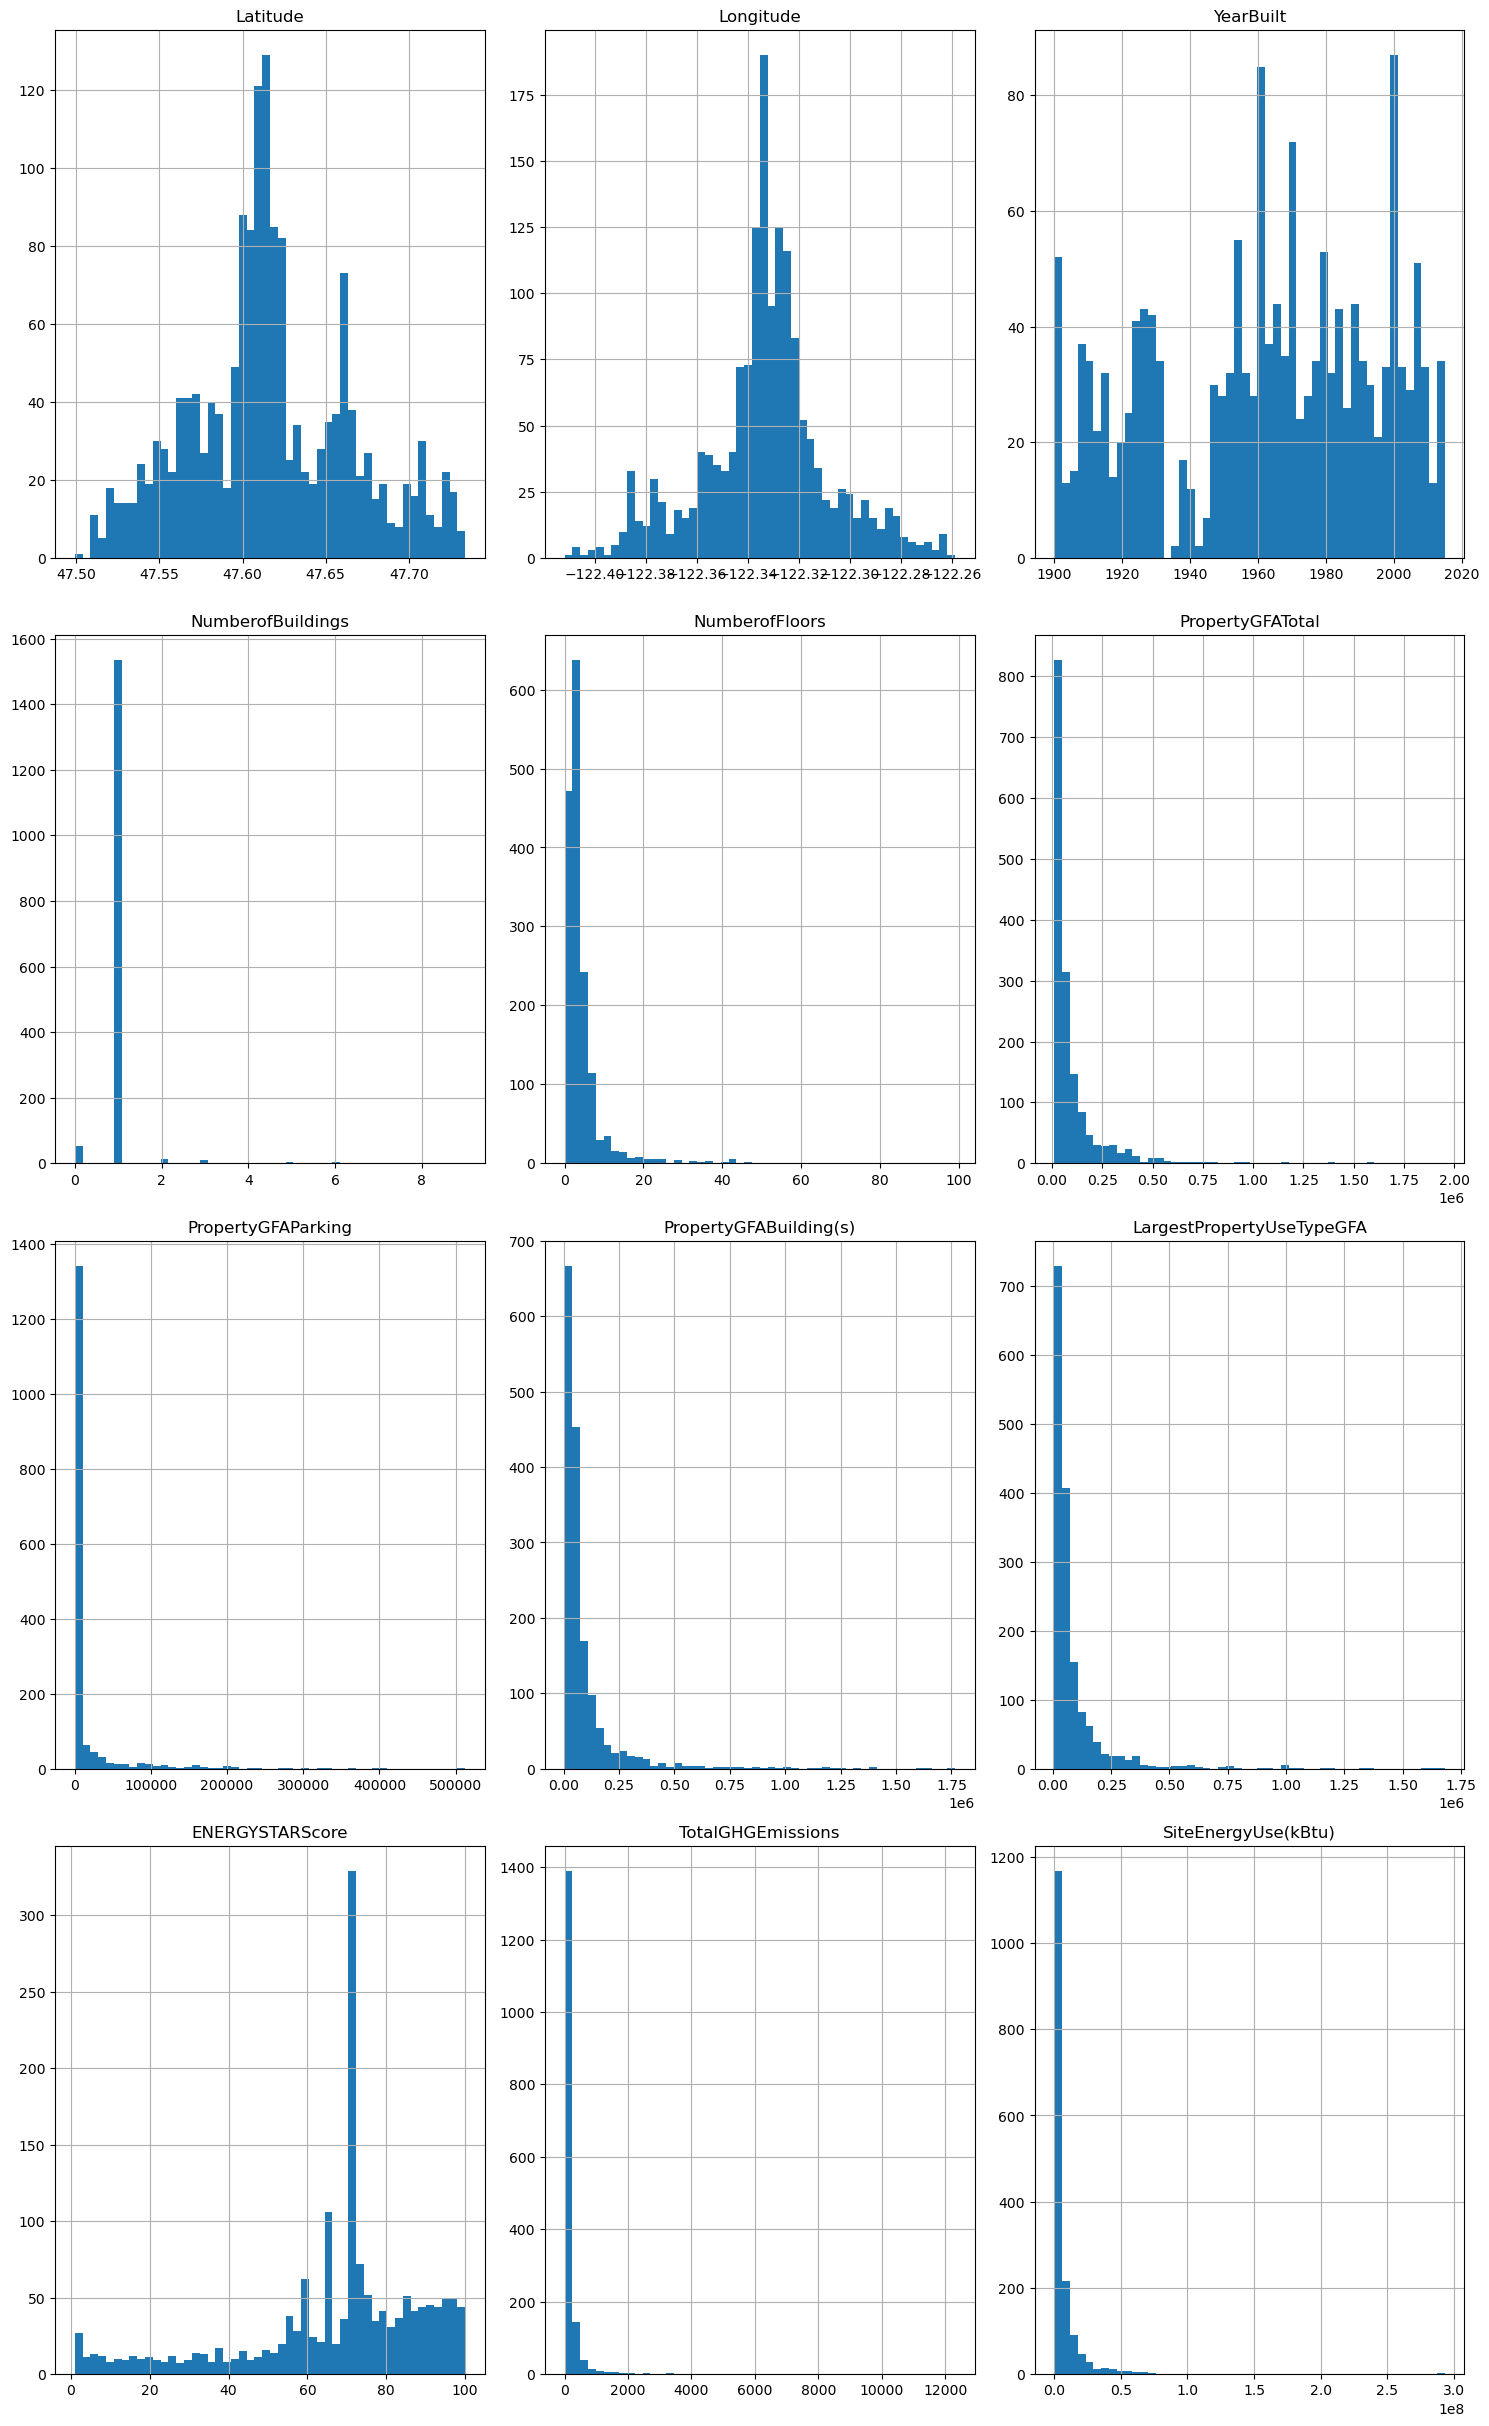

In [214]:
num_cols = building_consumption.select_dtypes(include='number').columns

fig, axes = plt.subplots(nrows=len(num_cols)//3 + 1, ncols=3, figsize=(15, 30))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    building_consumption[col].hist(ax=axes[i], bins=50)
    axes[i].set_title(col)
    axes[i].set_xlabel('')

# Masquer les axes vides
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Transformation logarithmique des variables asymétriques

La majorité des variables numériques présentent une distribution fortement asymétrique
(queue longue à droite) : la plupart des bâtiments ont de faibles valeurs, mais quelques
grands bâtiments (hôpitaux, universités) ont des valeurs extrêmement élevées.

Ce type de distribution pose problème pour les modèles de machine learning car :
- Le modèle accorde trop d'importance aux grandes valeurs
- Les relations entre variables ne sont pas linéaires
- Les prédictions sur les bâtiments "moyens" sont moins précises

La transformation logarithmique (np.log1p) permet de :
- Rendre la distribution plus symétrique et proche d'une loi normale
- Équilibrer le poids de chaque bâtiment dans l'apprentissage
- Linéariser les relations entre variables

Les colonnes concernées sont :
- Les surfaces : PropertyGFATotal, PropertyGFAParking, PropertyGFABuilding(s), LargestPropertyUseTypeGFA
- Les consommations : SiteEnergyUse(kBtu), SteamUse(kBtu), Electricity(kWh), NaturalGas(therms)
- Les émissions : TotalGHGEmissions, GHGEmissionsIntensity
- Les intensités énergétiques : SiteEUI(kBtu/sf), SourceEUI(kBtu/sf)

Note : np.log1p est utilisé à la place de np.log car il gère correctement les valeurs
égales à 0 (log(0) est indéfini, log1p(0) = 0).

In [217]:
cols_log = [
    'PropertyGFATotal', 'PropertyGFABuilding(s)',
    'LargestPropertyUseTypeGFA', 'SiteEnergyUse(kBtu)',  'TotalGHGEmissions'
]

for col in cols_log:
    building_consumption[col + '_log'] = np.log1p(building_consumption[col])



# Modélisation 

### Import des modules 

In [ ]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


### Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 

In [ ]:
# CODE FEATURE ENGINEERING

### Préparation des features pour la modélisation

A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation.
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
*  Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne.

In [ ]:
# CODE PREPARATION DES FEATURES

### Comparaison de différents modèles supervisés

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

In [1]:
# CODE COMPARAISON DES MODELES

### Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn. 

In [ ]:
# CODE OPTIMISATION ET INTERPRETATION DU MODELE